In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("data_B.csv")

df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x15309,CUS_0xaa66,April,NaN,32,841-06-2917,Architect,14995.29,NaN,...,Bad,4593.28,29.968714,3 Years and 2 Months,Yes,60.535964,54.73854091370111,Low_spent_Medium_value_payments,278.586245369556,Poor
1,1,0x8bb6,CUS_0x7d83,January,Dasguptaj,30,227-93-6471,Lawyer,74902.8,6272.900000,...,Bad,2900.49,28.086006,12 Years and 9 Months,Yes,534.751534,52.25901203477476,High_spent_Large_value_payments,280.27945391259857,Poor
2,2,0xe016,CUS_0x71aa,January,Nicholasq,22,632-01-7252,Lawyer,20574.71,1813.559167,...,Bad,2592.78,32.525087,12 Years and 1 Months,Yes,88.759975,77.89308197841973,Low_spent_Large_value_payments,284.70286002007293,Poor
3,3,0xbffb,CUS_0x59b6,February,Scuffhamk,53,315-03-3600,Writer,111090.06,9192.505000,...,Good,575.32,25.360743,27 Years and 6 Months,No,149.079658,436.7372848909153,Low_spent_Medium_value_payments,613.4335567793378,Standard
4,4,0xa96e,CUS_0x36a1,January,Miyoung Kimh,42,286-88-7128,Teacher,19214.965,1730.247083,...,Good,498.81,37.600265,28 Years and 9 Months,No,0.000000,217.7804724472987,!@9#%8,245.2442358860347,Good


In [3]:
print(df.shape)

(25000, 29)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22534 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21244 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [5]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].astype(str).value_counts().head())


Unnamed: 0
Unnamed: 0
24999    1
0        1
1        1
2        1
3        1
Name: count, dtype: int64

ID
ID
0x12b25    1
0x15309    1
0x8bb6     1
0xe016     1
0xbffb     1
Name: count, dtype: int64

Customer_ID
Customer_ID
CUS_0xb319    7
CUS_0x6070    7
CUS_0x8c13    7
CUS_0x302f    7
CUS_0xa663    7
Name: count, dtype: int64

Month
Month
March      3184
July       3175
January    3137
August     3136
April      3122
Name: count, dtype: int64

Name
Name
nan         2466
Nicko         17
Phila         15
Davidc        15
Jessicad      14
Name: count, dtype: int64

Age
Age
28    755
31    702
22    697
38    696
34    687
Name: count, dtype: int64

SSN
SSN
#F%$D@*&8      1334
748-06-7649       7
971-08-8220       7
743-80-2245       7
558-96-0647       6
Name: count, dtype: int64

Occupation
Occupation
_______       1792
Lawyer        1634
Scientist     1608
Accountant    1592
Engineer      1572
Name: count, dtype: int64

Annual_Income
Annual_Income
15361.32     7
59961.82     7
102

In [6]:
df.nunique().sort_values(ascending=False)

,0
Unnamed: 0,25000
ID,25000
Credit_Utilization_Ratio,25000
Monthly_Balance,24698
Amount_invested_monthly,22772
Annual_Income,12854
Customer_ID,11275
Outstanding_Debt,11226
SSN,11091
Total_EMI_per_month,10926


In [7]:
drop_cols = [
    'Unnamed: 0',
    'ID',
    'Customer_ID',
    'Name',
    'SSN'
]

df = df.drop(columns=drop_cols)

In [8]:
df["Type_of_Loan"].nunique()

5747

In [9]:
df = df.drop(columns=["Type_of_Loan"])

In [10]:
df['Age'] = df['Age'].astype(str)

df['Age'] = df['Age'].str.replace('_','')

df['Age'] = pd.to_numeric(
    df['Age'],
    errors='coerce'
)

In [11]:
df['Annual_Income'] = (
    df['Annual_Income']
    .astype(str)
    .str.replace('_','')
)

df['Annual_Income'] = pd.to_numeric(
    df['Annual_Income'],
    errors='coerce'
)

In [12]:
df['Num_of_Loan'] = (
    df['Num_of_Loan']
    .astype(str)
    .str.replace('_','')
)

df['Num_of_Loan'] = pd.to_numeric(
    df['Num_of_Loan'],
    errors='coerce'
)

In [13]:
df['Num_of_Delayed_Payment'] = (
    df['Num_of_Delayed_Payment']
    .astype(str)
    .str.replace('_','')
)

df['Num_of_Delayed_Payment'] = pd.to_numeric(
    df['Num_of_Delayed_Payment'],
    errors='coerce'
)

In [14]:
df['Changed_Credit_Limit'] = pd.to_numeric(
    df['Changed_Credit_Limit'],
    errors='coerce'
)

In [15]:
df['Outstanding_Debt'] = (
    df['Outstanding_Debt']
    .astype(str)
    .str.replace('_','')
)

df['Outstanding_Debt'] = pd.to_numeric(
    df['Outstanding_Debt'],
    errors='coerce'
)

In [16]:
df['Amount_invested_monthly'] = pd.to_numeric(
    df['Amount_invested_monthly'],
    errors='coerce'
)

In [17]:
df['Monthly_Balance'] = pd.to_numeric(
    df['Monthly_Balance'],
    errors='coerce'
)

In [18]:
def convert_credit_history(text):

    try:
        year = int(text.split(' Years')[0])

        month = int(
            text.split('and ')[1]
            .split(' Months')[0]
        )

        return year * 12 + month

    except:
        return np.nan

In [19]:
df['Credit_History_Age'] = (
    df['Credit_History_Age']
    .apply(convert_credit_history)
)

In [20]:
df['Occupation'] = df['Occupation'].replace(
    '_______',
    np.nan
)

In [21]:
df['Credit_Mix'] = df['Credit_Mix'].replace(
    '_',
    np.nan
)

In [22]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))


Column: Month
Month
March       3184
July        3175
January     3137
August      3136
April       3122
February    3106
May         3082
June        3058
Name: count, dtype: int64

Column: Occupation
Occupation
NaN              1792
Lawyer           1634
Scientist        1608
Accountant       1592
Engineer         1572
Architect        1570
Mechanic         1562
Writer           1559
Entrepreneur     1554
Media_Manager    1551
Developer        1511
Doctor           1509
Journalist       1508
Teacher          1498
Manager          1491
Musician         1489
Name: count, dtype: int64

Column: Credit_Mix
Credit_Mix
Standard    9075
Good        6042
NaN         5172
Bad         4711
Name: count, dtype: int64

Column: Payment_of_Min_Amount
Payment_of_Min_Amount
Yes    13043
No      8875
NM      3082
Name: count, dtype: int64

Column: Payment_Behaviour
Payment_Behaviour
Low_spent_Small_value_payments      6480
High_spent_Medium_value_payments    4445
Low_spent_Medium_value_payments     34

In [23]:
df['Payment_Behaviour'].value_counts()

,count
Payment_Behaviour,
Low_spent_Small_value_payments,6480
High_spent_Medium_value_payments,4445
Low_spent_Medium_value_payments,3433
High_spent_Large_value_payments,3396
High_spent_Small_value_payments,2817
Low_spent_Large_value_payments,2526
!@9#%8,1903


In [24]:
df['Payment_Behaviour'] = df[
    'Payment_Behaviour'
].replace(
    '!@9#%8',
    np.nan
)

In [25]:
df["Payment_of_Min_Amount"].value_counts()

,count
Payment_of_Min_Amount,
Yes,13043
No,8875
NM,3082


In [26]:
df['Payment_of_Min_Amount'] = (
    df['Payment_of_Min_Amount']
    .replace('NM', np.nan)
)

In [27]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].astype(str).value_counts().head())


Month
Month
March      3184
July       3175
January    3137
August     3136
April      3122
Name: count, dtype: int64

Age
Age
28    783
38    742
31    740
22    733
39    716
Name: count, dtype: int64

Occupation
Occupation
nan           1792
Lawyer        1634
Scientist     1608
Accountant    1592
Engineer      1572
Name: count, dtype: int64

Annual_Income
Annual_Income
102287.79    7
15910.33     7
92047.08     7
15361.32     7
88714.41     7
Name: count, dtype: int64

Monthly_Inhand_Salary
Monthly_Inhand_Salary
nan                   3756
1111.8608333333334       7
1362.11                  6
3852.096666666667        6
1905.030416666667        6
Name: count, dtype: int64

Num_Bank_Accounts
Num_Bank_Accounts
6    3260
8    3208
7    3193
5    3050
4    3018
Name: count, dtype: int64

Num_Credit_Card
Num_Credit_Card
5    4538
7    4162
6    4142
4    3566
3    3317
Name: count, dtype: int64

Interest_Rate
Interest_Rate
5     1227
8     1225
12    1212
6     1185
10    1158
Name: coun

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                23208 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21244 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    23267 non-null  float64
 11  Changed_Credit_Limit      24468 non-null  float64
 12  Num_Credit_Inquiries      24510 non-null  float64
 13  Credit_Mix                19828 non-null  object 
 14  Outsta

In [29]:
df.isnull().sum().sort_values(ascending=False)

,0
Credit_Mix,5172
Monthly_Inhand_Salary,3756
Payment_of_Min_Amount,3082
Credit_History_Age,2292
Amount_invested_monthly,2189
Payment_Behaviour,1903
Occupation,1792
Num_of_Delayed_Payment,1733
Changed_Credit_Limit,532
Num_Credit_Inquiries,490


In [30]:
missing_num_cols = [
    col for col in df.columns
    if df[col].isnull().sum() > 0
    and df[col].dtype in ['int64', 'float64']
]

print(missing_num_cols)

['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']


In [31]:
outlier_cols = []
non_outlier_cols = []

for col in missing_num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower) |
        (df[col] > upper)
    ).sum()

    if outlier_count > 0:
        outlier_cols.append(col)
    else:
        non_outlier_cols.append(col)

print("Outlier Columns:")
print(outlier_cols)

print("\nNo Outlier Columns:")
print(non_outlier_cols)

Outlier Columns:
['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Amount_invested_monthly', 'Monthly_Balance']

No Outlier Columns:
['Credit_History_Age']


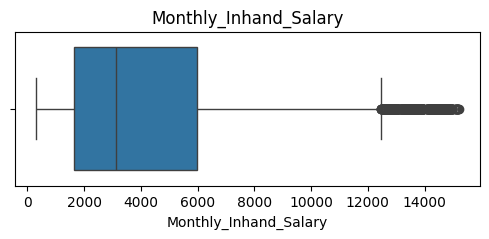

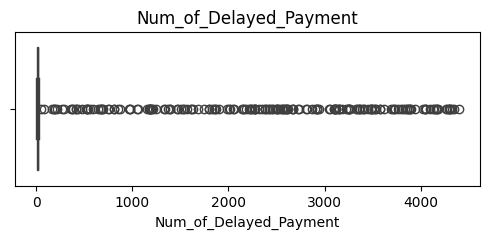

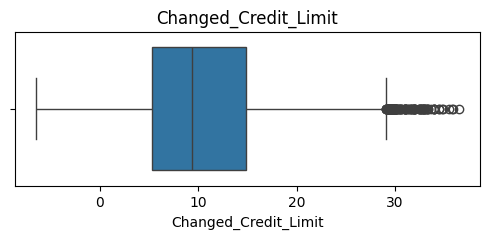

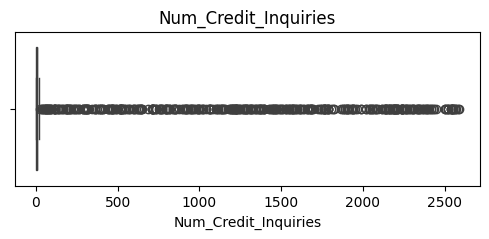

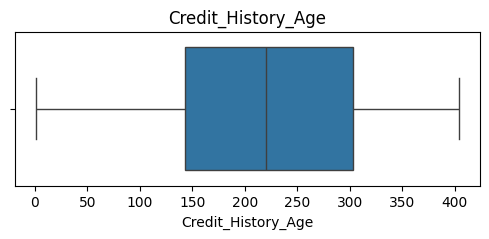

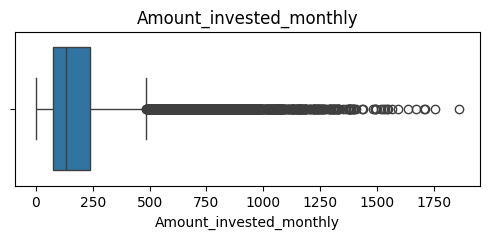

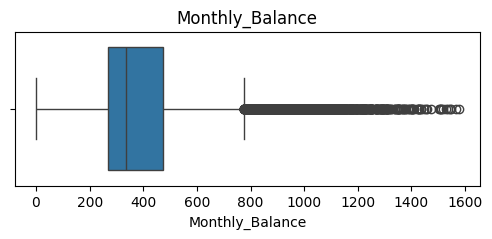

In [32]:
for col in missing_num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [33]:
mean_cols = ['Credit_History_Age']

for col in mean_cols:
    df[col] = df[col].fillna(df[col].mean())

In [34]:
median_cols = ['Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Amount_invested_monthly', 'Monthly_Balance']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

In [35]:
cat_cols = [
    'Occupation',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [36]:
# Perbaikan Usia (18 - 85)
df.loc[(df["Age"] < 18) | (df["Age"] > 85), "Age"] = np.nan
df["Age"] = df["Age"].fillna(df["Age"].median()).astype(int)

In [37]:
# Jumlah Rekening Bank (0 - 15)
df.loc[(df["Num_Bank_Accounts"] < 0) | (df["Num_Bank_Accounts"] > 15),
       "Num_Bank_Accounts"] = np.nan
df["Num_Bank_Accounts"] = df["Num_Bank_Accounts"].fillna(
    df["Num_Bank_Accounts"].median()
).astype(int)

In [38]:
# Jumlah Kartu Kredit (0 - 15)
df.loc[(df["Num_Credit_Card"] < 0) | (df["Num_Credit_Card"] > 15),
       "Num_Credit_Card"] = np.nan
df["Num_Credit_Card"] = df["Num_Credit_Card"].fillna(
    df["Num_Credit_Card"].median()
).astype(int)

In [39]:
# Interest Rate (1% - 40%)
df.loc[(df["Interest_Rate"] < 1) | (df["Interest_Rate"] > 40),
       "Interest_Rate"] = np.nan
df["Interest_Rate"] = df["Interest_Rate"].fillna(
    df["Interest_Rate"].median()
).astype(int)

In [40]:
# Jumlah Pinjaman (0 - 15)
df.loc[(df["Num_of_Loan"] < 0) | (df["Num_of_Loan"] > 15),
       "Num_of_Loan"] = np.nan
df["Num_of_Loan"] = df["Num_of_Loan"].fillna(
    df["Num_of_Loan"].median()
).astype(int)

In [41]:
# Delay dari due date (negatif jadi 0)
df.loc[df["Delay_from_due_date"] < 0, "Delay_from_due_date"] = 0

In [42]:
# Jumlah keterlambatan pembayaran (0 - 30)
df.loc[(df["Num_of_Delayed_Payment"] < 0) |
       (df["Num_of_Delayed_Payment"] > 30),
       "Num_of_Delayed_Payment"] = np.nan
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].fillna(
    df["Num_of_Delayed_Payment"].median()
).astype(int)

In [43]:
# Credit inquiries (0 - 20)
df.loc[(df["Num_Credit_Inquiries"] < 0) |
       (df["Num_Credit_Inquiries"] > 20),
       "Num_Credit_Inquiries"] = np.nan
df["Num_Credit_Inquiries"] = df["Num_Credit_Inquiries"].fillna(
    df["Num_Credit_Inquiries"].median()
).astype(int)

In [44]:
# EMI per bulan (tidak boleh > gaji bulanan)
df.loc[df["Total_EMI_per_month"] > df["Monthly_Inhand_Salary"],
       "Total_EMI_per_month"] = np.nan
df["Total_EMI_per_month"] = df["Total_EMI_per_month"].fillna(
    df["Total_EMI_per_month"].median()
)

In [45]:
# Sinkronisasi Annual Income vs Monthly Salary
calculated = df["Monthly_Inhand_Salary"] * 12

mismatch = (
    (df["Annual_Income"] > calculated * 1.5) |
    (df["Annual_Income"] < calculated * 0.5)
)

df.loc[mismatch, "Annual_Income"] = calculated[mismatch]

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    25000 non-null  int64  
 11  Changed_Credit_Limit      25000 non-null  float64
 12  Num_Credit_Inquiries      25000 non-null  int64  
 13  Credit_Mix                25000 non-null  object 
 14  Outsta

In [47]:
df.columns

Index(['Month', 'Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df["Credit_Score"].value_counts()

,count
Credit_Score,
Standard,13257
Poor,7197
Good,4546


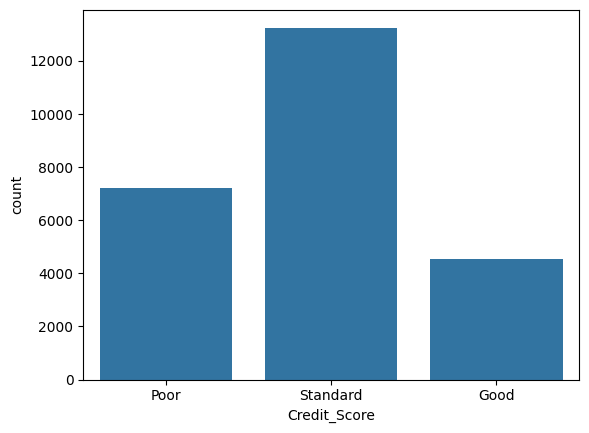

In [50]:
sns.countplot(data=df,x="Credit_Score")
plt.show()

In [51]:
X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (25000, 22)
y Shape : (25000,)


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(20000, 22)
(5000, 22)


In [53]:
num_cols = X_train.select_dtypes(
    include=["int64","float64"]
).columns

cat_cols = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical Features")
print(num_cols)

print("\nCategorical Features")
print(cat_cols)

Numerical Features
Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

Categorical Features
Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object')


In [54]:
X_train = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)

In [55]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [58]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr.predict(
    X_test_scaled
)

In [59]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

y_pred_dt = dt.predict(
    X_test
)

In [60]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [62]:
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    return accuracy, precision, recall, f1

In [63]:
lr_result = evaluate_model(
    y_test,
    y_pred_lr
)

dt_result = evaluate_model(
    y_test,
    y_pred_dt
)

rf_result = evaluate_model(
    y_test,
    y_pred_rf
)

In [64]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_result[0],
        dt_result[0],
        rf_result[0]
    ],

    "Precision":[
        lr_result[1],
        dt_result[1],
        rf_result[1]
    ],

    "Recall":[
        lr_result[2],
        dt_result[2],
        rf_result[2]
    ],

    "F1-Score":[
        lr_result[3],
        dt_result[3],
        rf_result[3]
    ]
})

results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.7364,0.737963,0.7364,0.736878
0,Logistic Regression,0.6530,0.653713,0.6530,0.650373
1,Decision Tree,0.6388,0.639410,0.6388,0.639087


In [65]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

        Good       0.64      0.69      0.66       909
        Poor       0.75      0.71      0.73      1440
    Standard       0.77      0.77      0.77      2651

    accuracy                           0.74      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



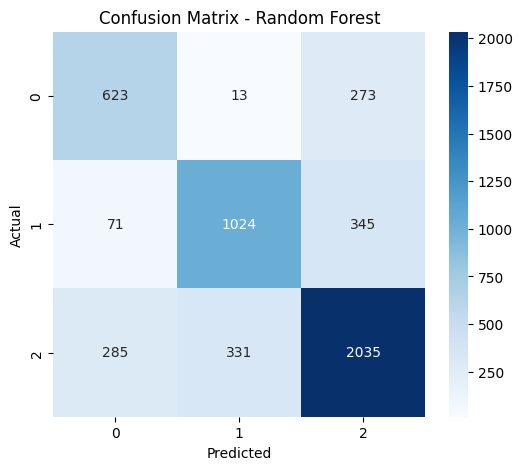

In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [67]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,Outstanding_Debt,0.099747
5,Interest_Rate,0.075329
7,Delay_from_due_date,0.058539
9,Changed_Credit_Limit,0.056836
13,Credit_History_Age,0.050536
14,Total_EMI_per_month,0.043251
4,Num_Credit_Card,0.042745
16,Monthly_Balance,0.042639
10,Num_Credit_Inquiries,0.042335
15,Amount_invested_monthly,0.041913


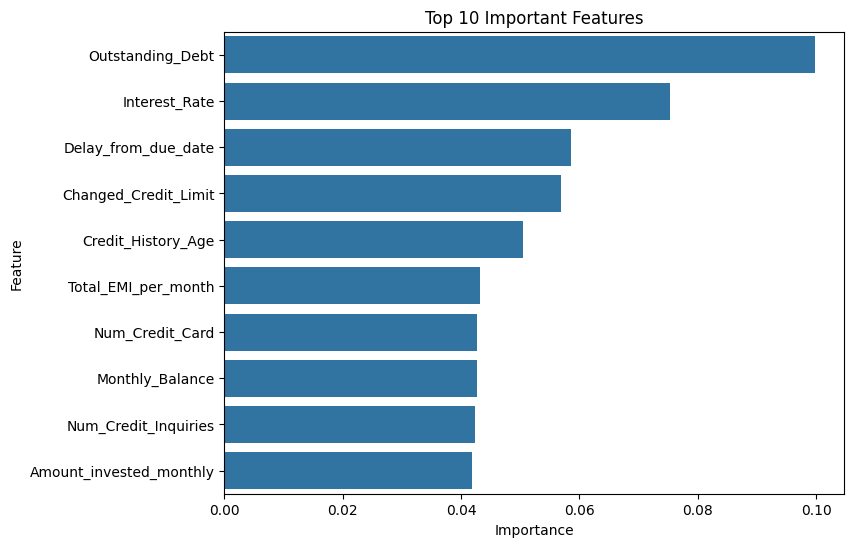

In [68]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [69]:
df.to_csv(
    "data_B_clean.csv",
    index=False
)

Dataset awal punya 29 kolom, tapi setelah proses cleaning tersisa 22 fitur (kolom target Credit_Score dipisah sebagai y). Kolom identitas yang tidak relevan untuk prediksi dihapus di awal: Unnamed: 0, ID, Customer_ID, Name, SSN, dan Type_of_Loan (dihapus karena terlalu banyak variasi kombinasi teks).

Preprocessing yang dilakukan:
- Pembersihan tipe data, banyak kolom numerik awalnya masih object karena ada karakter underscore (_) atau simbol aneh (misal #F%$D@*&8). Dibersihkan dengan str.replace lalu pd.to_numeric.
- Transformasi format khusus, kolom Credit_History_Age yang awalnya teks ("3 Years and 2 Months") dikonversi jadi total bulan pakai fungsi custom.
- Penanganan nilai placeholder tidak valid, nilai seperti "_______" (Occupation), "_" (Credit_Mix), "!@9#%8" (Payment_Behaviour), "NM" (Payment_of_Min_Amount) diganti jadi NaN karena sebenarnya itu data kosong yang disamarkan.
- Imputasi missing value : Median untuk kolom numerik yang punya outlier (dideteksi pakai IQR), yaitu Monthly_Inhand_Salary, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries, Amount_invested_monthly, Monthly_Balance. Mean untuk kolom tanpa outlier (Credit_History_Age). Modus untuk kolom kategorikal (Occupation, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour).
- Validasi logika bisnis / capping nilai tidak masuk akal : Age dibatasi 18–85 tahun, Num_Bank_Accounts & Num_Credit_Card 0–15, Interest_Rate 1–40%, Num_of_Loan 0–15, Delay_from_due_date tidak boleh negatif (di-set 0), Num_of_Delayed_Payment 0–30, Num_Credit_Inquiries 0–20. EMI bulanan divalidasi tidak boleh melebihi gaji bulanan, dan Annual_Income disinkronkan dengan Monthly_Inhand_Salary × 12.
- Encoding kategorikal, one-hot encoding (get_dummies, drop_first=True) untuk 5 kolom kategorikal, lalu kolom train/test diselaraskan (align).
- Scaling, StandardScaler diterapkan khusus untuk data yang dipakai Logistic Regression (model linear sensitif skala), Decision Tree dan Random Forest pakai data tanpa scaling (tidak sensitif skala).
- Split data, 80:20 train test


Eksperimen yang dilakukan untuk mencari model terbaik adalah perbandingan tiga algoritma klasifikasi dengan metode yang sama.

Data yang sama dibagi 80:20 (20.000 data latih, 5.000 data uji).

Model yang diuji:
- Logistic Regression, dilatih menggunakan data yang sudah distandarisasi (StandardScaler), karena model linear ini sensitif terhadap skala fitur.
- Decision Tree, dilatih menggunakan data mentah (tanpa scaling), karena model berbasis pohon tidak terpengaruh skala fitur.
- Random Forest (200 pohon/n_estimators=200), juga dilatih tanpa scaling dengan alasan yang sama.

Metrik evaluasi:
Keempat metrik dihitung untuk tiap model, yaitu accuracy, precision, recall, dan F1-score. semuanya dengan average="weighted" karena kelas target tidak seimbang (Standard 13.257, Poor 7.197, Good 4.546). Penggunaan weighted average ini penting agar kelas mayoritas tidak mendominasi penilaian.

Hasil perbandingan:
- random forest memiliki accuracy 0.7364, F1 Score 0.7369
- logistic regression memiliki accuracy 0.6530, F1 Score 0.6504
- Decision Tree memiliki accuracy 0.6388, F1 score 0.6391

Random Forest unggul cukup jauh dari dua model lainnya di semua metrik, sehingga dipilih sebagai model terbaik.

Setelah Random Forest terpilih sebagai model terbaik, dilakukan dua analisis tambahan yaitu:
- Classification report per kelas, untuk melihat apakah performa model merata di semua kelas atau timpang. Hasilnya performa terbaik di kelas Standard (f1=0.77) dan terlemah di kelas Good (f1=0.66), sejalan dengan jumlah data yang tidak seimbang.
- Confusion matrix, untuk melihat pola kesalahan prediksi, kelas mana yang paling sering tertukar dengan kelas lain.
- Feature importance, untuk mengidentifikasi variabel apa yang paling berkontribusi terhadap keputusan Random Forest, hasilnya Outstanding_Debt, Interest_Rate, dan Delay_from_due_date adalah tiga fitur paling berpengaruh.